# Spiking Neural Network for Retinal Image Classification

This notebook trains a convolutional spiking neural network (SNN) on the APTOS 2019 retinal dataset.
Run cells top to bottom to train and evaluate, and optionally launch a Gradio demo at the end.

## Optional installs

Run this cell only if your environment is missing the required packages.

In [1]:
# Uncomment if needed in a fresh environment
# %pip install -q snntorch gradio torch torchvision tqdm

In [2]:
from pathlib import Path
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, transforms
import snntorch as snn
from snntorch import surrogate, spikegen, utils as snn_utils
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
SEED = 42
NOTEBOOK_DIR = Path.cwd()
RETINAL_ROOT = NOTEBOOK_DIR.parent
DATA_ROOT = RETINAL_ROOT / "dataset" / "aptos2019-blindness-detection" / "imagefolder"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUTPUT_DIR / "snn_best.pth"

IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_STEPS = 25
BETA = 0.5
SLOPE = 25
DATA_PROP = 1.0

USE_GRAYSCALE = False
NORMALIZE = True
AUGMENT = True
BALANCE_SAMPLER = True
ENCODING = "rate"  # "rate" or "repeat"
NUM_WORKERS = 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_ROOT}")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_targets(dataset):
    if isinstance(dataset, Subset):
        base_targets = np.asarray(dataset.dataset.targets, dtype=np.int64)
        return base_targets[dataset.indices]
    return np.asarray(dataset.targets, dtype=np.int64)


def stratified_subset_indices(targets, data_prop: float, seed: int) -> np.ndarray:
    if data_prop >= 1.0:
        return np.arange(len(targets))
    rng = np.random.default_rng(seed)
    targets = np.asarray(targets, dtype=np.int64)
    indices = []
    for cls in np.unique(targets):
        cls_idx = np.where(targets == cls)[0]
        n_keep = max(1, int(round(len(cls_idx) * data_prop)))
        chosen = rng.choice(cls_idx, size=n_keep, replace=False)
        indices.extend(chosen.tolist())
    rng.shuffle(indices)
    return np.asarray(indices, dtype=np.int64)


def subset_dataset(dataset, data_prop: float, seed: int):
    if data_prop >= 1.0:
        return dataset
    targets = get_targets(dataset)
    indices = stratified_subset_indices(targets, data_prop, seed)
    return Subset(dataset, indices)


def describe_distribution(targets) -> dict:
    counts = {}
    for t in targets:
        counts[int(t)] = counts.get(int(t), 0) + 1
    return dict(sorted(counts.items()))


def compute_class_weights(targets) -> torch.Tensor:
    targets = np.asarray(targets, dtype=np.int64)
    counts = np.bincount(targets)
    n_total = targets.shape[0]
    n_classes = len(counts)
    weights = n_total / (n_classes * counts)
    return torch.tensor(weights, dtype=torch.float32)


def build_transforms(image_size: int, use_grayscale: bool, normalize: bool, augment: bool):
    base = [transforms.Resize((image_size, image_size))]
    if use_grayscale:
        base.append(transforms.Grayscale(num_output_channels=1))
    train_list = base.copy()
    if augment:
        train_list.extend([transforms.RandomHorizontalFlip(), transforms.RandomRotation(10)])
    train_list.append(transforms.ToTensor())
    val_list = base + [transforms.ToTensor()]
    if normalize:
        if use_grayscale:
            train_list.append(transforms.Normalize((0.5,), (0.5,)))
            val_list.append(transforms.Normalize((0.5,), (0.5,)))
        else:
            train_list.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
            val_list.append(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)))
    return transforms.Compose(train_list), transforms.Compose(val_list)


def build_dataloaders(
    data_root: Path,
    batch_size: int,
    image_size: int,
    data_prop: float,
    num_workers: int,
    seed: int,
    augment: bool,
    use_grayscale: bool,
    normalize: bool,
    balance_sampler: bool,
    ):
    train_dir = data_root / "train"
    val_dir = data_root / "val"
    train_transform, val_transform = build_transforms(image_size, use_grayscale, normalize, augment)

    train_dataset = datasets.ImageFolder(str(train_dir), transform=train_transform)
    val_dataset = datasets.ImageFolder(str(val_dir), transform=val_transform)
    train_dataset = subset_dataset(train_dataset, data_prop, seed)

    train_targets = get_targets(train_dataset)
    class_weights = compute_class_weights(train_targets)
    class_names = train_dataset.dataset.classes if isinstance(train_dataset, Subset) else train_dataset.classes

    if balance_sampler:
        weights = [1.0 / np.bincount(train_targets)[t] for t in train_targets]
        sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            num_workers=num_workers,
            drop_last=False,
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            drop_last=False,
        )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=False,
    )

    return train_loader, val_loader, class_weights, class_names, val_transform

In [5]:
set_seed(SEED)

train_loader, val_loader, class_weights, class_names, val_transform = build_dataloaders(
    data_root=DATA_ROOT,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    data_prop=DATA_PROP,
    num_workers=NUM_WORKERS,
    seed=SEED,
    augment=AUGMENT,
    use_grayscale=USE_GRAYSCALE,
    normalize=NORMALIZE,
    balance_sampler=BALANCE_SAMPLER,
    )

NUM_CLASSES = len(class_names)
INPUT_CHANNELS = 1 if USE_GRAYSCALE else 3

train_targets = get_targets(train_loader.dataset)
print("Classes:", class_names)
print("Train distribution:", describe_distribution(train_targets))
print("Class weights:", [round(w, 4) for w in class_weights.tolist()])

Classes: ['0', '1', '2', '3', '4']
Train distribution: {0: 1444, 1: 296, 2: 799, 3: 154, 4: 236}
Class weights: [0.4057, 1.9791, 0.7332, 3.8039, 2.4822]


In [6]:
class SpikingConvNet(nn.Module):
    def __init__(self, input_channels: int, num_classes: int, image_size: int, beta: float, slope: int, num_steps: int):
        super().__init__()
        self.num_steps = num_steps
        spike_grad = surrogate.fast_sigmoid(slope=slope)

        self.conv1 = nn.Conv2d(input_channels, 16, kernel_size=5)
        self.pool1 = nn.MaxPool2d(2)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5)
        self.pool2 = nn.MaxPool2d(2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True)

        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, image_size, image_size)
            feat = self.pool2(self.conv2(self.pool1(self.conv1(dummy))))
            flat_dim = int(feat.view(1, -1).shape[1])

        self.fc1 = nn.Linear(flat_dim, num_classes)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad, init_hidden=True, output=True)

    def forward(self, x):
        spk_rec = []
        mem_rec = []
        snn_utils.reset(self)
        for step in range(self.num_steps):
            cur1 = self.pool1(self.conv1(x[step]))
            lif1_out = self.lif1(cur1)
            spk1 = lif1_out[0] if isinstance(lif1_out, tuple) else lif1_out
            cur2 = self.pool2(self.conv2(spk1))
            lif2_out = self.lif2(cur2)
            spk2 = lif2_out[0] if isinstance(lif2_out, tuple) else lif2_out
            cur3 = self.fc1(spk2.view(spk2.size(0), -1))
            lif_out = self.lif_out(cur3)
            if isinstance(lif_out, tuple):
                spk_out = lif_out[0]
                mem_out = lif_out[1] if len(lif_out) > 1 else lif_out[0]
            else:
                spk_out = lif_out
                mem_out = lif_out
            spk_rec.append(spk_out)
            mem_rec.append(mem_out)
        return torch.stack(spk_rec), torch.stack(mem_rec)


def encode_batch(x: torch.Tensor, num_steps: int, encoding: str) -> torch.Tensor:
    if encoding == "rate":
        if NORMALIZE:
            x_rate = torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)
        else:
            x_rate = torch.clamp(x, 0.0, 1.0)
        return spikegen.rate(x_rate, num_steps=num_steps)
    if encoding == "repeat":
        return x.unsqueeze(0).repeat(num_steps, 1, 1, 1, 1)
    raise ValueError(f"Unknown encoding: {encoding}")

In [7]:
def forward_to_logits(spk_rec: torch.Tensor, mem_rec: torch.Tensor) -> torch.Tensor:
    return spk_rec.sum(dim=0)


def run_epoch(model, loader, loss_fn, optimizer=None, scheduler=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for x, y in tqdm(loader, desc="train" if is_train else "eval", leave=False):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        x_spk = encode_batch(x, NUM_STEPS, ENCODING)
        if is_train:
            optimizer.zero_grad()
        spk_rec, mem_rec = model(x_spk)
        logits = forward_to_logits(spk_rec, mem_rec)
        loss = loss_fn(logits, y)
        if is_train:
            loss.backward()
            optimizer.step()
            if scheduler is not None:
                scheduler.step()
        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_seen += y.size(0)

    avg_loss = total_loss / max(1, total_seen)
    avg_acc = total_correct / max(1, total_seen)
    return avg_loss, avg_acc


@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    all_targets = []
    all_preds = []
    for x, y in loader:
        x = x.to(DEVICE)
        x_spk = encode_batch(x, NUM_STEPS, ENCODING)
        spk_rec, mem_rec = model(x_spk)
        logits = forward_to_logits(spk_rec, mem_rec)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_targets.extend(y.numpy().tolist())
    return np.asarray(all_targets), np.asarray(all_preds)


def confusion_matrix_np(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

In [8]:
model = SpikingConvNet(
    input_channels=INPUT_CHANNELS,
    num_classes=NUM_CLASSES,
    image_size=IMAGE_SIZE,
    beta=BETA,
    slope=SLOPE,
    num_steps=NUM_STEPS,
).to(DEVICE)

loss_fn = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
 )

history = []
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        model, train_loader, loss_fn, optimizer=optimizer, scheduler=scheduler
    )
    val_loss, val_acc = run_epoch(model, val_loader, loss_fn, optimizer=None)
    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.3f}"
    )

print(f"Best val accuracy: {best_val_acc:.3f}")
print(f"Best checkpoint: {CHECKPOINT_PATH}")

Epoch 01 | train loss 1.6094 acc 0.194 | val loss 1.6094 acc 0.492


Epoch 02 | train loss 1.6094 acc 0.210 | val loss 1.6094 acc 0.492


Epoch 03 | train loss 1.6094 acc 0.197 | val loss 1.6094 acc 0.492


Epoch 04 | train loss 1.6094 acc 0.207 | val loss 1.6094 acc 0.492


Epoch 05 | train loss 1.6094 acc 0.188 | val loss 1.6094 acc 0.492


...

Epoch 16 | train loss 1.6094 acc 0.197 | val loss 1.6094 acc 0.492


Epoch 17 | train loss 1.6094 acc 0.197 | val loss 1.6094 acc 0.492


Epoch 18 | train loss 1.6094 acc 0.189 | val loss 1.6094 acc 0.492


Epoch 19 | train loss 1.6094 acc 0.199 | val loss 1.6094 acc 0.492


Epoch 20 | train loss 1.6094 acc 0.189 | val loss 1.6094 acc 0.492
Best val accuracy: 0.492
Best checkpoint: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/Spike Classifier/outputs/snn_best.pth


Validation accuracy: 0.492


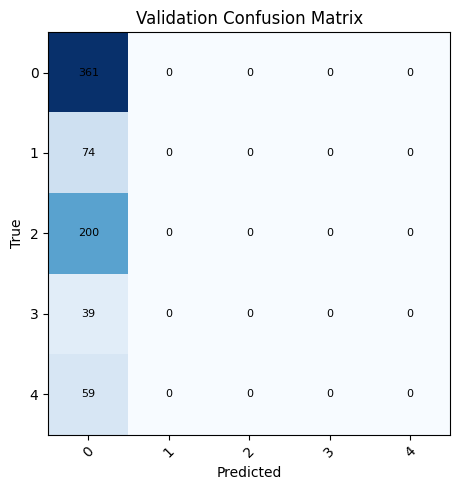

In [9]:
if CHECKPOINT_PATH.exists():
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

y_true, y_pred = collect_predictions(model, val_loader)
val_acc = (y_true == y_pred).mean()
print(f"Validation accuracy: {val_acc:.3f}")

cm = confusion_matrix_np(y_true, y_pred, NUM_CLASSES)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.title("Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(NUM_CLASSES), class_names, rotation=45)
plt.yticks(range(NUM_CLASSES), class_names)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
import csv

class UnlabeledImageDataset(torch.utils.data.Dataset):
    def __init__(self, root: Path, transform):
        self.paths = sorted([p for p in Path(root).glob("*.png")])
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        image = Image.open(path)
        if USE_GRAYSCALE:
            image = image.convert("L")
        else:
            image = image.convert("RGB")
        return self.transform(image), path.name


@torch.no_grad()
def predict_unlabeled(model, loader):
    model.eval()
    results = []
    for x, names in loader:
        x = x.to(DEVICE)
        x_spk = encode_batch(x, NUM_STEPS, ENCODING)
        spk_rec, mem_rec = model(x_spk)
        logits = forward_to_logits(spk_rec, mem_rec)
        preds = logits.argmax(dim=1).cpu().tolist()
        for name, pred in zip(names, preds):
            results.append((name, class_names[pred]))
    return results


test_dir = DATA_ROOT / "test"
if test_dir.exists():
    test_dataset = UnlabeledImageDataset(test_dir, val_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    predictions = predict_unlabeled(model, test_loader)
    csv_path = OUTPUT_DIR / "test_predictions.csv"
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["image", "label"])
        writer.writerows(predictions)
    print(f"Saved predictions to: {csv_path}")
else:
    print(f"No unlabeled test folder found at: {test_dir}")

Saved predictions to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/Spike Classifier/outputs/test_predictions.csv


## Optional Gradio demo

This launches a small demo app so you can upload an image and see the model prediction.

In [11]:
import gradio as gr

if CHECKPOINT_PATH.exists():
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()

@torch.no_grad()
def predict_image(image):
    if USE_GRAYSCALE:
        image = image.convert("L")
    else:
        image = image.convert("RGB")
    x = val_transform(image).unsqueeze(0).to(DEVICE)
    x_spk = encode_batch(x, NUM_STEPS, ENCODING)
    spk_rec, mem_rec = model(x_spk)
    logits = forward_to_logits(spk_rec, mem_rec)
    pred = logits.argmax(dim=1).item()
    return class_names[pred]

demo = gr.Interface(fn=predict_image, inputs="image", outputs="label", title="Retinal SNN classifier")
demo.launch(share=True)

/media/aejaz/New Volume/Projects/SNN/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://dbee38ef20b4e1c952.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
